<a href="https://colab.research.google.com/github/useDeep/learn_ml/blob/main/LInear_regression_using_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
data= pd.read_csv('sample_data/data.csv', header= None, names= ['Population', 'Profit'])


In [ ]:
m= len(data)
X= np.append(np.ones([m, 1]), np.array(data["Population"]).reshape([m, 1]), axis= 1)
y= np.array(data["Profit"]).reshape([m, 1])


Text(0.5, 1.0, 'Relation between population and profit')

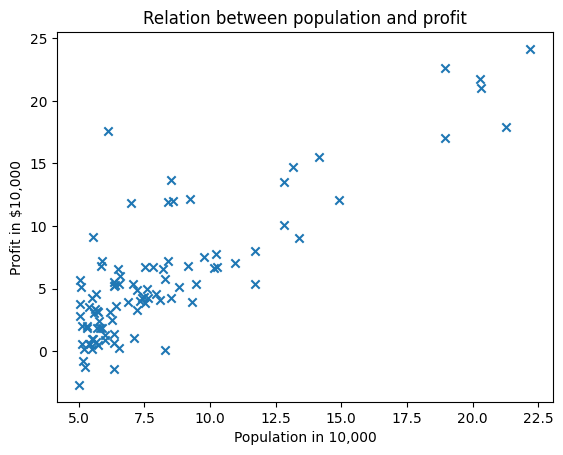

In [ ]:
plt.scatter(data['Population'], data['Profit'], marker= 'x')
plt.xlabel('Population in 10,000')
plt.ylabel('Profit in $10,000')
plt.title('Relation between population and profit')

In [ ]:
def cost_function(X, y, theta):
  m= len(y)
  H = X @ theta
  squared_errors= (H- y)**2
  cost= (1/ (2* m)) * np.sum(squared_errors)

  return cost

In [ ]:
initial_theta= np.zeros([2, 1])

p= cost_function(X, y, initial_theta)
p

np.float64(32.072733877455676)

In [ ]:
def gradient_descent(X, y, theta, alpha, iterations):
  m= len(y)
  J_history= []
  for i in range(iterations):
    H= X @ theta
    error= H- y
    gradient= (1/ m)* (X.T @ error)

    theta= theta - alpha * gradient
    cost= (1/ (2* m)* np.sum(error** 2))
    J_history.append(cost)

  return theta, J_history

In [ ]:
alpha= 0.01
iterations= 1000
theta, J_history= gradient_descent(X, y, initial_theta, alpha, iterations)
theta

array([[-3.24140214],
       [ 1.1272942 ]])

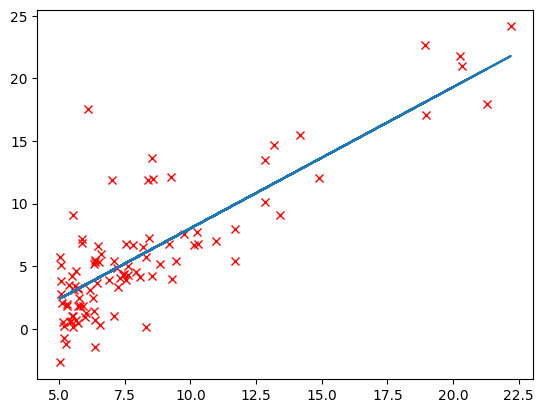

In [ ]:
plt.plot(X[:, 1], y, 'rx', label= "Training Data")
plt.plot(X[:, 1], X.dot(theta), label= "Linear Regression")

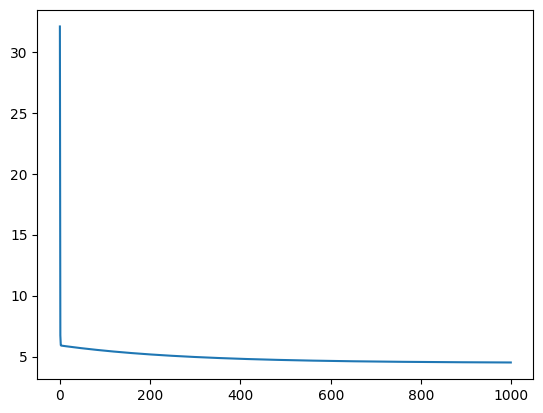

In [ ]:
plt.plot(J_history)

In [ ]:
prediction= np.array([1, 3.5]).dot(theta) * 1000
"In a city with a population of 35000, the profit is predicted to be $%.2f" % prediction

<ipython-input-14-09089d18619b>:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "In a city with a population of 35000, the profit is predicted to be $%.2f" % prediction


'In a city with a population of 35000, the profit is predicted to be $704.13'

# Multivaraite Linear Regression

In [ ]:
data= pd.read_csv('sample_data/data2.csv', header= None, names= ["Size", "Bedrooms", "Price"])
m= len(data)


In [ ]:
size= np.array((data["Size"]))
bedrooms= np.array((data["Bedrooms"]))
y= np.array((data['Price'])).reshape(m, 1)
X= np.array([size, bedrooms]).T

X

array([[2104,    3],
       [1600,    3],
       [2400,    3],
       [1416,    2],
       [3000,    4],
       [1985,    4],
       [1534,    3],
       [1427,    3],
       [1380,    3],
       [1494,    3],
       [1940,    4],
       [2000,    3],
       [1890,    3],
       [4478,    5],
       [1268,    3],
       [2300,    4],
       [1320,    2],
       [1236,    3],
       [2609,    4],
       [3031,    4],
       [1767,    3],
       [1888,    2],
       [1604,    3],
       [1962,    4],
       [3890,    3],
       [1100,    3],
       [1458,    3],
       [2526,    3],
       [2200,    3],
       [2637,    3],
       [1839,    2],
       [1000,    1],
       [2040,    4],
       [3137,    3],
       [1811,    4],
       [1437,    3],
       [1239,    3],
       [2132,    4],
       [4215,    4],
       [2162,    4],
       [1664,    2],
       [2238,    3],
       [2567,    4],
       [1200,    3],
       [ 852,    2],
       [1852,    4],
       [1203,    3]])

In [ ]:
theta_init= np.ones([3, 1])

In [ ]:
def normalize(X):
  mu= np.mean(X, axis= 0)
  sigma= np.std(X, axis= 0)

  X_norm= (X- mu)/ sigma

  return X_norm, mu, sigma

In [ ]:
X, mu, sigma= normalize(X)
X

array([[ 1.31415422e-01, -2.26093368e-01],
       [-5.09640698e-01, -2.26093368e-01],
       [ 5.07908699e-01, -2.26093368e-01],
       [-7.43677059e-01, -1.55439190e+00],
       [ 1.27107075e+00,  1.10220517e+00],
       [-1.99450507e-02,  1.10220517e+00],
       [-5.93588523e-01, -2.26093368e-01],
       [-7.29685755e-01, -2.26093368e-01],
       [-7.89466782e-01, -2.26093368e-01],
       [-6.44465993e-01, -2.26093368e-01],
       [-7.71822042e-02,  1.10220517e+00],
       [-8.65999486e-04, -2.26093368e-01],
       [-1.40779041e-01, -2.26093368e-01],
       [ 3.15099326e+00,  2.43050370e+00],
       [-9.31923697e-01, -2.26093368e-01],
       [ 3.80715024e-01,  1.10220517e+00],
       [-8.65782986e-01, -1.55439190e+00],
       [-9.72625673e-01, -2.26093368e-01],
       [ 7.73743478e-01,  1.10220517e+00],
       [ 1.31050078e+00,  1.10220517e+00],
       [-2.97227261e-01, -2.26093368e-01],
       [-1.43322915e-01, -1.55439190e+00],
       [-5.04552951e-01, -2.26093368e-01],
       [-4.

In [ ]:
x0= np.ones(m)

X= np.c_[x0, X]

X

array([[ 1.00000000e+00,  1.31415422e-01, -2.26093368e-01],
       [ 1.00000000e+00, -5.09640698e-01, -2.26093368e-01],
       [ 1.00000000e+00,  5.07908699e-01, -2.26093368e-01],
       [ 1.00000000e+00, -7.43677059e-01, -1.55439190e+00],
       [ 1.00000000e+00,  1.27107075e+00,  1.10220517e+00],
       [ 1.00000000e+00, -1.99450507e-02,  1.10220517e+00],
       [ 1.00000000e+00, -5.93588523e-01, -2.26093368e-01],
       [ 1.00000000e+00, -7.29685755e-01, -2.26093368e-01],
       [ 1.00000000e+00, -7.89466782e-01, -2.26093368e-01],
       [ 1.00000000e+00, -6.44465993e-01, -2.26093368e-01],
       [ 1.00000000e+00, -7.71822042e-02,  1.10220517e+00],
       [ 1.00000000e+00, -8.65999486e-04, -2.26093368e-01],
       [ 1.00000000e+00, -1.40779041e-01, -2.26093368e-01],
       [ 1.00000000e+00,  3.15099326e+00,  2.43050370e+00],
       [ 1.00000000e+00, -9.31923697e-01, -2.26093368e-01],
       [ 1.00000000e+00,  3.80715024e-01,  1.10220517e+00],
       [ 1.00000000e+00, -8.65782986e-01

In [ ]:
def gradient_descent(X, y, theta, alpha, iterations):
  J_history= []

  for i in range(iterations):
    H= X @ theta
    error= H- y
    gradient= (1/ m)* (X.T @ error)

    theta= theta - alpha * gradient
    cost= (1/ (2* m))* np.sum(error** 2)
    J_history.append(cost)

  return theta, J_history

In [ ]:
theta, J_history= gradient_descent(X, y, theta_init, alpha= 0.01, iterations=1000)

In [ ]:
theta

array([[340397.96357849],
       [108742.65627253],
       [ -5873.22993368]])

Text(0.5, 1.0, 'Cost per iteration')

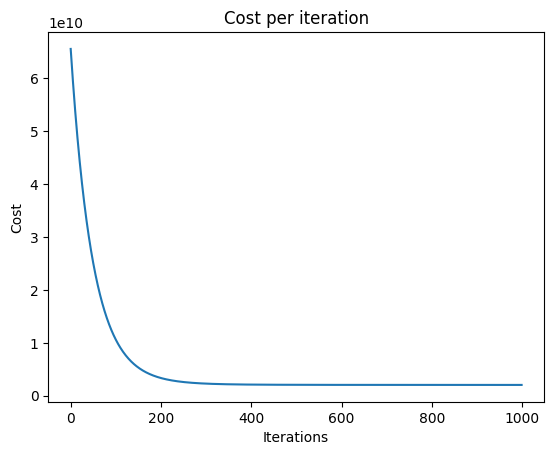

In [ ]:
plt.plot(J_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost per iteration")

In [ ]:
input= [1, (1650- mu[0])/ sigma[0], (3- mu[1]/ sigma[1])]
price= theta.T @ np.array(input)

"For a house of 1650 sq feet iwht 3 rooms, the price is predicted as $%.2f" % price

<ipython-input-84-95c2435bf6a3>:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "For a house of 1650 sq feet iwht 3 rooms, the price is predicted as $%.2f" % price


'For a house of 1650 sq feet iwht 3 rooms, the price is predicted as $299006.39'

# Normal Equations [ O(n**3) ]

In [ ]:
def normal_eq(X, y, theta_init):
  theta= (np.linalg.inv(X.T @ X)) @ (X.T @ y)

  return theta

In [ ]:
theta= normal_eq(X, y, theta_init)

theta

array([[340412.65957447],
       [109447.79646964],
       [ -6578.35485416]])

In [ ]:
input= [1, (1650- mu[0])/ sigma[0], (3- mu[1]/ sigma[1])]
price= theta.T @ np.array(input)

"For a house of 1650 sq feet iwht 3 rooms, the price is predicted as $%.2f" % price

<ipython-input-91-95c2435bf6a3>:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "For a house of 1650 sq feet iwht 3 rooms, the price is predicted as $%.2f" % price


'For a house of 1650 sq feet iwht 3 rooms, the price is predicted as $299560.46'